# 02 - Análisis exploratorio del dataset

En este notebook se realiza el análisis exploratorio del dataset CIC-IDS2017
previamente limpio y procesado.

El objetivo es estudiar las características del tráfico de red, analizar la
distribución entre tráfico benigno y ataques, identificar desequilibrios
y explorar las variables que puedan resultar más relevantes para la posterior
construcción del modelo de detección de amenazas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = Path("../data/processed/cic_ids2017_clean.parquet")

df = pd.read_parquet(DATA_FILE)

print(f"Registros: {len(df):,}")
print(f"Columnas: {len(df.columns)}")

Registros: 2,520,798
Columnas: 80


## Distribución entre tráfico benigno y ataques

Se analiza la distribución de la variable objetivo binaria `is_attack`, que
distingue entre tráfico benigno (`0`) y tráfico asociado a algún tipo de
ataque (`1`).

Este análisis permite conocer el grado de desequilibrio existente entre ambas
clases, importante para la posterior selección, entrenamiento y
evaluación de los modelos de clasificación.

In [2]:
attack_counts = df["is_attack"].value_counts().sort_index()
attack_percentages = df["is_attack"].value_counts(normalize=True).sort_index() * 100

print("Distribución:")
print(f"Tráfico benigno (0): {attack_counts[0]:,} ({attack_percentages[0]:.2f} %)")
print(f"Ataques (1):         {attack_counts[1]:,} ({attack_percentages[1]:.2f} %)")

Distribución:
Tráfico benigno (0): 2,095,057 (83.11 %)
Ataques (1):         425,741 (16.89 %)


## Distribución de los tipos de tráfico

Además de la clasificación binaria entre tráfico benigno y ataque, el dataset
contiene la etiqueta original `Label`, que identifica diferentes tipos de
actividad maliciosa.

Se analiza la distribución de estas clases para conocer qué amenazas están
representadas en el dataset y detectar posibles desequilibrios entre los
distintos tipos de ataque.

In [3]:
label_counts = df["Label"].value_counts()
label_percentages = df["Label"].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "Registros": label_counts,
    "Porcentaje": label_percentages
})

print(distribution)

                            Registros  Porcentaje
Label                                            
BENIGN                        2095057   83.110864
DoS Hulk                       172846    6.856797
DDoS                           128014    5.078313
PortScan                        90694    3.597829
DoS GoldenEye                   10286    0.408045
FTP-Patator                      5931    0.235283
DoS slowloris                    5385    0.213623
DoS Slowhttptest                 5228    0.207395
SSH-Patator                      3219    0.127698
Bot                              1948    0.077277
Web Attack � Brute Force         1470    0.058315
Web Attack � XSS                  652    0.025865
Infiltration                       36    0.001428
Web Attack � Sql Injection         21    0.000833
Heartbleed                         11    0.000436


## Visualización de la distribución binaria

Se representa gráficamente la distribución entre tráfico benigno y tráfico
malicioso. La visualización permite apreciar el desequilibrio existente entre
ambas clases antes del entrenamiento del modelo.

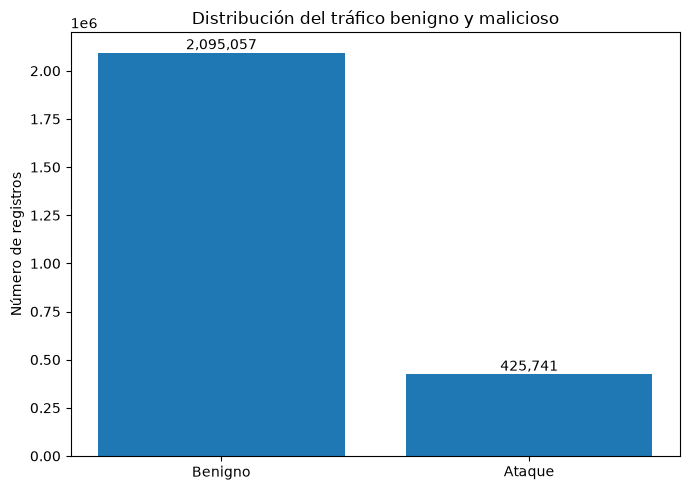

In [4]:
binary_counts = df["is_attack"].value_counts().sort_index()

labels = ["Benigno", "Ataque"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, binary_counts.values)

plt.title("Distribución del tráfico benigno y malicioso")
plt.ylabel("Número de registros")

for bar, value in zip(bars, binary_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Distribución de los tipos de ataque

Se analiza la distribución de las diferentes categorías de ataque presentes
en el dataset, excluyendo el tráfico benigno.

Esta representación permite observar el desequilibrio entre
las distintas amenazas y valorar la viabilidad de utilizar estas categorías
como clases en un problema de clasificación multiclase.

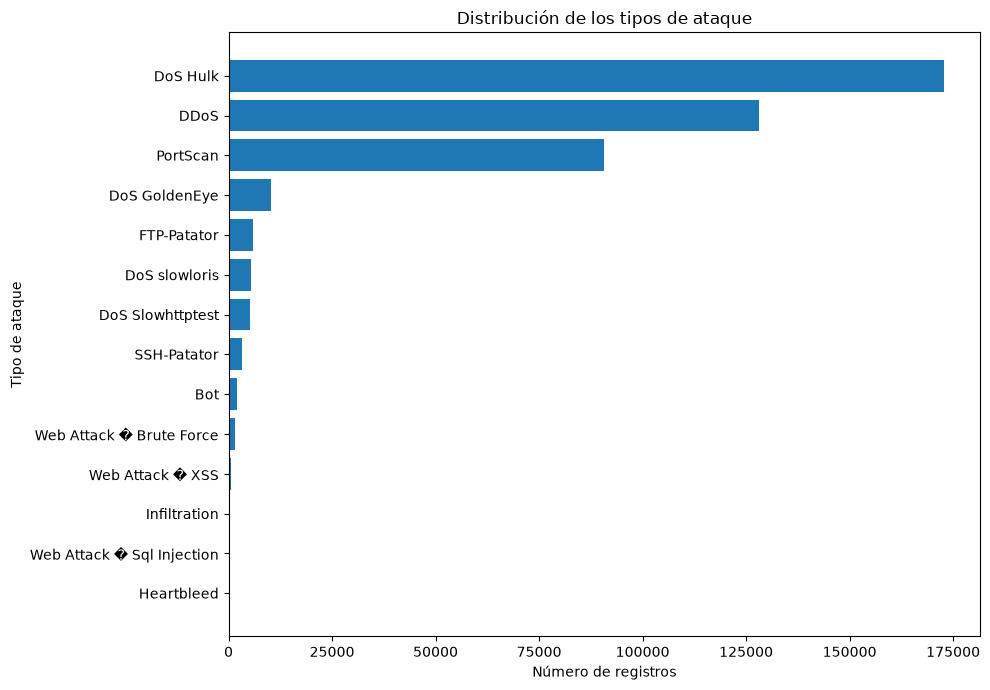

In [5]:
attack_type_counts = (
    df.loc[df["is_attack"] == 1, "Label"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 7))

plt.barh(attack_type_counts.index, attack_type_counts.values)

plt.title("Distribución de los tipos de ataque")
plt.xlabel("Número de registros")
plt.ylabel("Tipo de ataque")

plt.tight_layout()
plt.show()

## Análisis de variables constantes

Antes de analizar la relación entre las características y la variable objetivo,
se comprueba si existen variables con un único valor en todo el dataset.

Las variables constantes no aportan capacidad discriminativa al modelo, ya que
presentan el mismo valor para todas las observaciones, por lo que pueden
eliminarse antes del entrenamiento.

In [7]:
feature_columns = [
    column for column in df.columns
    if column not in ["Label", "is_attack"]
]

unique_counts = df[feature_columns].nunique()

constant_columns = unique_counts[unique_counts <= 1]

print(f"Variables predictoras analizadas: {len(feature_columns)}")
print(f"Variables constantes: {len(constant_columns)}")
print()
print(constant_columns)

Variables predictoras analizadas: 78
Variables constantes: 8

Bwd PSH Flags           1
Bwd URG Flags           1
Fwd Avg Bytes/Bulk      1
Fwd Avg Packets/Bulk    1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Bwd Avg Bulk Rate       1
dtype: int64


## Selección inicial de variables predictoras

Se han identificado ocho variables constantes en todo el dataset. Al no
presentar variabilidad entre las observaciones, estas características no
aportan información útil para discriminar entre tráfico benigno y malicioso.

Por este motivo, se excluyen del conjunto de variables predictoras utilizado
para los análisis posteriores y el entrenamiento de los modelos.

In [8]:
X = df[feature_columns].drop(columns=constant_columns.index)
y = df["is_attack"]

print(f"Variables predictoras originales: {len(feature_columns)}")
print(f"Variables constantes eliminadas: {len(constant_columns)}")
print(f"Variables predictoras restantes: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")

Variables predictoras originales: 78
Variables constantes eliminadas: 8
Variables predictoras restantes: 70
Registros: 2,520,798


## Relación de las variables con la clase objetivo

Se analiza la correlación entre las variables predictoras y la variable
objetivo binaria `is_attack`.

Este análisis constituye una primera aproximación para identificar
características potencialmente relacionadas con la presencia de tráfico
malicioso. La correlación no se utiliza por sí sola como criterio definitivo
de selección, ya que pueden existir relaciones no lineales o interacciones
entre variables que no queden reflejadas mediante esta medida.

In [9]:
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)

print("Variables con mayor correlación absoluta con is_attack:")
print()
print(correlations.head(20))

Variables con mayor correlación absoluta con is_attack:

Bwd Packet Length Std     0.611719
Bwd Packet Length Max     0.596472
Bwd Packet Length Mean    0.594413
Avg Bwd Segment Size      0.594413
Packet Length Std         0.573487
Max Packet Length         0.555474
Packet Length Variance    0.536776
Average Packet Size       0.521616
Packet Length Mean        0.520950
Fwd IAT Std               0.506110
Idle Max                  0.475610
Flow IAT Max              0.471520
Idle Mean                 0.470861
Fwd IAT Max               0.470800
Idle Min                  0.458438
Flow IAT Std              0.410972
Fwd IAT Total             0.280069
Flow Duration             0.279008
Min Packet Length        -0.276949
FIN Flag Count            0.271944
dtype: float64


### Variables con mayor correlación con la presencia de ataques

A continuación se representan las variables con mayor correlación absoluta
respecto a la variable objetivo `is_attack`.

Los resultados muestran que varias características relacionadas con el tamaño
de los paquetes, los tiempos entre paquetes y los periodos de inactividad del
flujo presentan una relación destacada con la presencia de tráfico malicioso.

El análisis de correlación se utiliza con carácter exploratorio y no implica
que estas variables sean suficientes de forma individual para detectar un
ataque.

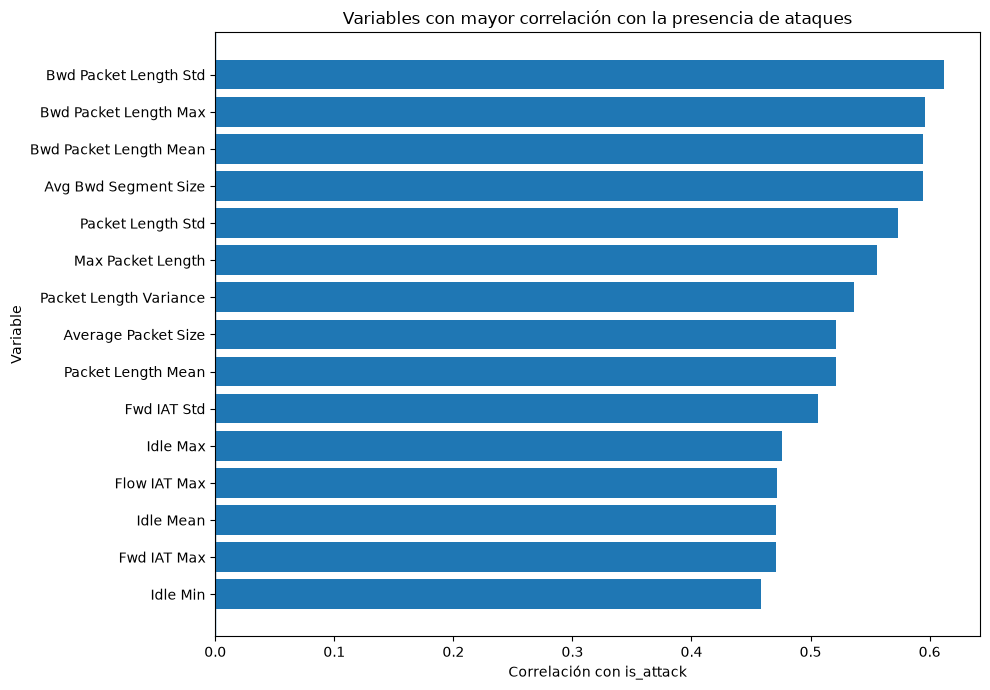

In [10]:
top_correlations = correlations.head(15).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_correlations.index,
    top_correlations.values
)

plt.title("Variables con mayor correlación con la presencia de ataques")
plt.xlabel("Correlación con is_attack")
plt.ylabel("Variable")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Análisis de correlación entre variables predictoras

Además de estudiar la relación de las variables con la clase objetivo, es
conveniente analizar la correlación existente entre las propias variables
predictoras.

Una correlación muy elevada entre dos características puede indicar que ambas
aportan información similar o redundante. Este análisis va a permitir identificar
posibles grupos de variables fuertemente relacionadas antes de construir el
modelo de detección.

In [11]:
#Matriz de correlación entre las variables predictoras
feature_corr = df[feature_columns].corr().abs()

#Nos quedamos sólo con la parte superior de la matriz para no contar cada pareja dos veces
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

#Se extraen las parejas con correlación muy alta
high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.95]


print(f"Parejas de variables con correlación >= 0.95: {len(high_corr_pairs)}")
print()
print(high_corr_pairs.head(30))

Parejas de variables con correlación >= 0.95: 39

Fwd PSH Flags                SYN Flag Count                 1.000000
Fwd Header Length            Fwd Header Length.1            1.000000
Fwd URG Flags                CWE Flag Count                 1.000000
Bwd Packet Length Mean       Avg Bwd Segment Size           1.000000
Total Fwd Packets            Subflow Fwd Packets            1.000000
Total Backward Packets       Subflow Bwd Packets            1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size           1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.000000
Total Length of Fwd Packets  Subflow Fwd Bytes              0.999999
Total Fwd Packets            Total Backward Packets         0.999070
Subflow Fwd Packets          Subflow Bwd Packets            0.999070
Total Fwd Packets            Subflow Bwd Packets            0.999070
Total Backward Packets       Subflow Fwd Packets            0.999070
Flow Duration                Fwd IAT Total           

### Identificación de variables redundantes

El análisis anterior ha mostrado la existencia de numerosas correlaciones muy
elevadas entre las variables predictoras. Algunas características presentan correlaciones perfectas o casi.

Con el objetivo de reducir información redundante, se identifican las variables
que podrían eliminarse utilizando un umbral de correlación absoluta de 0,95.

En esta fase se identifican las variables candidatas. La eliminación
se realizará posteriormente como parte del proceso de preparación de los datos
para el entrenamiento.

In [12]:
#Identificación de variables candidatas a eliminar por alta correlación

corr_matrix = df[feature_columns].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


redundant_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] >= 0.95)
]


print(f"Variables predictoras actuales: {len(feature_columns)}")
print(f"Variables candidatas a eliminar: {len(redundant_features)}")
print(f"Variables que quedarían: {len(feature_columns) - len(redundant_features)}")
print()


for variable in redundant_features:
    print(variable)

Variables predictoras actuales: 78
Variables candidatas a eliminar: 23
Variables que quedarían: 55

Total Backward Packets
Total Length of Bwd Packets
Fwd Packet Length Std
Bwd Packet Length Mean
Bwd Packet Length Std
Fwd IAT Total
Fwd IAT Max
Fwd Packets/s
Packet Length Std
SYN Flag Count
CWE Flag Count
ECE Flag Count
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Header Length.1
Subflow Fwd Packets
Subflow Fwd Bytes
Subflow Bwd Packets
Subflow Bwd Bytes
Idle Mean
Idle Max
Idle Min


In [13]:
#Actualizamos la lista de variables predictoras después de haber eliminado las variables constantes

feature_columns = [
    column for column in df.columns
    if column not in ["Label", "is_attack"]
]


print(f"Variables predictoras disponibles actualmente: {len(feature_columns)}")

Variables predictoras disponibles actualmente: 78


In [14]:
#Eliminar las variables constantes

constant_columns = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate"
]

df = df.drop(columns=constant_columns)

# Actualizamos la lista de variables predictoras
feature_columns = [
    column for column in df.columns
    if column not in ["Label", "is_attack"]
]


print(f"Columnas totales del dataset: {len(df.columns)}")
print(f"Variables predictoras: {len(feature_columns)}")
print(f"Registros: {len(df):,}")

Columnas totales del dataset: 72
Variables predictoras: 70
Registros: 2,520,798


In [15]:
# analizar la correlación entre las 70 variables predictoras restantes

corr_matrix = df[feature_columns].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.95]

print(f"Parejas de variables con correlación >= 0.95: {len(high_corr_pairs)}")
print()
print(high_corr_pairs)

Parejas de variables con correlación >= 0.95: 39

Fwd PSH Flags                SYN Flag Count                 1.000000
Fwd Header Length            Fwd Header Length.1            1.000000
Fwd URG Flags                CWE Flag Count                 1.000000
Bwd Packet Length Mean       Avg Bwd Segment Size           1.000000
Total Fwd Packets            Subflow Fwd Packets            1.000000
Total Backward Packets       Subflow Bwd Packets            1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size           1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.000000
Total Length of Fwd Packets  Subflow Fwd Bytes              0.999999
Total Fwd Packets            Total Backward Packets         0.999070
Subflow Fwd Packets          Subflow Bwd Packets            0.999070
Total Fwd Packets            Subflow Bwd Packets            0.999070
Total Backward Packets       Subflow Fwd Packets            0.999070
Flow Duration                Fwd IAT Total           

### Selección de variables ante alta correlación

La presencia de múltiples pares de variables con una correlación absoluta igual
o superior a 0,95 indica un elevado grado de redundancia entre algunas
características del dataset.

Para reducir esta redundancia, se aplica un criterio de selección basado en la
relación con la variable objetivo. Cuando dos variables presentan una
correlación muy elevada entre sí, se priorizará la conservación de la que
presenta una mayor correlación absoluta con `is_attack`.

Este procedimiento permite reducir el número de características manteniendo,
dentro de cada grupo de variables altamente relacionadas, las que muestran mayor asociación individual con la variable objetivo.

In [16]:
#Correlación absoluta de cada variable predictora con el objetivo
target_corr = (
    df[feature_columns + ["is_attack"]]
    .corr()["is_attack"]
    .drop("is_attack")
    .abs()
)

#Ordenars las variables de mayor a menor relación con el objetivo
ordered_features = target_corr.sort_values(ascending=False).index.tolist()

selected_features = []

for feature in ordered_features:
    # conseervar la variable si no está altamente correlacionada con ninguna de las seleccionadas
    if not any(
        corr_matrix.loc[feature, selected] >= 0.95
        for selected in selected_features
    ):
        selected_features.append(feature)


removed_by_correlation = [
    feature for feature in feature_columns
    if feature not in selected_features
]


print(f"Variables antes de reducir redundancia: {len(feature_columns)}")
print(f"Variables eliminadas por alta correlación: {len(removed_by_correlation)}")
print(f"Variables seleccionadas: {len(selected_features)}")
print()


print("Variables eliminadas:")
for feature in removed_by_correlation:
    print(f" - {feature}")

Variables antes de reducir redundancia: 70
Variables eliminadas por alta correlación: 22
Variables seleccionadas: 48

Variables eliminadas:
 - Flow Duration
 - Total Fwd Packets
 - Total Length of Fwd Packets
 - Total Length of Bwd Packets
 - Fwd Packet Length Std
 - Bwd Packet Length Max
 - Flow Packets/s
 - Flow IAT Max
 - Fwd IAT Max
 - Max Packet Length
 - Packet Length Mean
 - SYN Flag Count
 - RST Flag Count
 - CWE Flag Count
 - Avg Fwd Segment Size
 - Avg Bwd Segment Size
 - Fwd Header Length.1
 - Subflow Fwd Packets
 - Subflow Bwd Packets
 - Subflow Bwd Bytes
 - Idle Mean
 - Idle Min


In [17]:
#Aplicar la selección de características

df = df.drop(columns=removed_by_correlation)

#Actualizar la lista definitiva de variables predictoras
feature_columns = selected_features.copy()


print(f"Registros: {len(df):,}")
print(f"Variables predictoras finales: {len(feature_columns)}")
print(f"Columnas totales: {len(df.columns)}")

Registros: 2,520,798
Variables predictoras finales: 48
Columnas totales: 50


## Preparación de los datos para Machine Learning

Una vez finalizado el análisis exploratorio y la selección de
características, se prepara el conjunto de datos que se va a utilizar para
entrenar y evaluar los modelos de detección.

Las 48 variables predictoras seleccionadas constituyen la matriz de
características (`X`), mientras que la variable binaria `is_attack`
constituye la variable objetivo (`y`).

El conjunto de datos se divide en un 80 % para entrenamiento y un 20 % para
prueba. Se utiliza una división estratificada para mantener en ambos
subconjuntos una proporción similar de tráfico benigno y malicioso.

In [18]:
from sklearn.model_selection import train_test_split

X = df[feature_columns].copy()
y = df["is_attack"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Dataset completo:      {len(X):,}")
print(f"Entrenamiento:         {len(X_train):,}")
print(f"Prueba:                {len(X_test):,}")
print()

print(f"Variables predictoras: {X_train.shape[1]}")
print()

print("Distribución entrenamiento:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print()
print("Distribución prueba:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Dataset completo:      2,520,798
Entrenamiento:         2,016,638
Prueba:                504,160

Variables predictoras: 48

Distribución entrenamiento:
is_attack
0    1676045
1     340593
Name: count, dtype: int64
is_attack
0    83.11
1    16.89
Name: proportion, dtype: float64

Distribución prueba:
is_attack
0    419012
1     85148
Name: count, dtype: int64
is_attack
0    83.11
1    16.89
Name: proportion, dtype: float64


### División en entrenamiento, validación y prueba

Para evitar utilizar el conjunto de prueba durante la toma de decisiones del
modelo, el conjunto de datos se divide en tres subconjuntos independientes:

- **Entrenamiento (70 %):** utilizado para ajustar los parámetros del modelo.
- **Validación (10 %):** utilizado para seleccionar configuraciones,
  hiperparámetros y criterios de decisión.
- **Prueba (20 %):** reservado para la evaluación final.

La división se realiza de forma estratificada para conservar la proporción
entre tráfico benigno y malicioso, y se utiliza un fijo para garantizar
la reproducibilidad de los experimentos.

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)


print(f"Entrenamiento: {len(X_train):,} ({len(X_train) / len(X) * 100:.1f} %)")
print(f"Validación:    {len(X_val):,} ({len(X_val) / len(X) * 100:.1f} %)")
print(f"Prueba:        {len(X_test):,} ({len(X_test) / len(X) * 100:.1f} %)")
print()

print("Distribución entrenamiento:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución validación:")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nDistribución prueba:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Entrenamiento: 1,764,558 (70.0 %)
Validación:    252,080 (10.0 %)
Prueba:        504,160 (20.0 %)

Distribución entrenamiento:
is_attack
0    83.11
1    16.89
Name: proportion, dtype: float64

Distribución validación:
is_attack
0    83.11
1    16.89
Name: proportion, dtype: float64

Distribución prueba:
is_attack
0    83.11
1    16.89
Name: proportion, dtype: float64


### Escalado de las variables predictoras

Las características del dataset presentan escalas y rangos de valores
diferentes. Esto puede afectar a modelos basados
en redes neuronales, ya que las variables con magnitudes elevadas pueden tener
una influencia desproporcionada durante el entrenamiento.

Se utiliza `StandardScaler` para estandarizar las variables predictoras. El
escalador se ajusta utilizando el conjunto de entrenamiento y
después se aplica a los conjuntos de validación y prueba.

Este procedimiento evita utilizar información procedente de los conjuntos
reservados para evaluación durante la fase de preparación del modelo y reduce
el riesgo de *data leakage*.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print(f"Train:      {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test:       {X_test_scaled.shape}")

Train:      (1764558, 48)
Validation: (252080, 48)
Test:       (504160, 48)


In [21]:
print("Comprobación del conjunto de entrenamiento:")
print(f"Media media:                {X_train_scaled.mean():.6f}")
print(f"Desviación estándar media: {X_train_scaled.std():.6f}")

print("\nValores mínimo y máximo:")
print(f"Mínimo: {X_train_scaled.min():.2f}")
print(f"Máximo: {X_train_scaled.max():.2f}")

Comprobación del conjunto de entrenamiento:
Media media:                -0.000000
Desviación estándar media: 1.000000

Valores mínimo y máximo:
Mínimo: -1246.02
Máximo: 353.60
